# Born in Simulation — V2: Fixing the Seed Formula

**Seminar in AI (340.910) — JKU Linz | Saqib Ali Khan (K12343661)**

This is the second iteration (V2) of the sim-to-real domain randomization experiment. It exists to fix a specific bug discovered in V1.

## The V1 bug this version fixes

V1 used the seed formula `cycle_seed = 42 + obj_idx × 100,000 + (i % texture_level)` and generated 500 images per class. Because the image index `i` never reached the higher texture levels, `i % texture_level` simply equalled `i` for levels 500, 1000, and 5000 — meaning **all three of those levels generated identical training data**. Their apparent accuracy differences in V1 were just training noise, not real diversity effects.

## What V2 changes

- **Fixed seed formula:** `cycle_seed = 42 + obj_idx × 1,000,000 + texture_level × 100 + (i % texture_level)`. The `texture_level × 100` term shifts each level into its own seed range so no two levels collide.
- **Doubled the data:** 1,000 images per class (up from 500), so Level 1000 reaches its intended 1,000 genuinely unique renders.

Everything else matches V1: same ResNet-18 (pretrained, fully fine-tuned), same fixed 10 epochs, same architecture. This isolates the effect of the seed fix and the extra data.

> **Note:** This notebook documents the intermediate V2 step. The final, most rigorous version is V3 (5,000 images/class, early stopping, stratified split, from-scratch ablation).

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import os, csv, random, time
from pathlib import Path

import numpy as np
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import models, transforms

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import pybullet as p
import pybullet_data

from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

Device : cuda
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM   : 6.4 GB
PyTorch: 2.2.1+cu121


## Configuration

All paths and hyperparameters. V2 outputs go to separate `_v2` folders so they never collide with V1 or V3 results. Note the fixed 10 epochs — V2 uses simple fixed-length training (early stopping was only introduced in V3).

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment")
MESH_DIR    = BASE_DIR / "3D mesh for simulation (16k )"
RGB_DIR     = BASE_DIR / "RGB images for testing"

# V2-specific output folders
SYNTH_DIR_V2   = BASE_DIR / "synthetic_images_v2"
MODELS_DIR_V2  = BASE_DIR / "trained_models_v2"
RESULTS_DIR_V2 = BASE_DIR / "results_v2"

for folder in [SYNTH_DIR_V2, MODELS_DIR_V2, RESULTS_DIR_V2]:
    folder.mkdir(exist_ok=True)

# ── YCB objects (5 classes) ────────────────────────────────────────────────
OBJECTS = [
    "025_mug",
    "006_mustard_bottle",
    "035_power_drill",
    "024_bowl",
    "021_bleach_cleanser",
]
CLASS_MAP = {i: obj for i, obj in enumerate(OBJECTS)}

# ── Texture diversity levels ───────────────────────────────────────────────
TEXTURE_LEVELS = [10, 100, 500, 1000, 5000]
ALL_LEVELS     = [0] + TEXTURE_LEVELS

# ── V2 dataset / training settings ─────────────────────────────────────────
IMAGES_V2  = 1000          # images per class (doubled from V1's 500)
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 10            # fixed-length training (no early stopping in V2)
LR         = 1e-4

# ── Verify inputs ──────────────────────────────────────────────────────────
print("Input folders:")
print(f"  Mesh dir : {'OK' if MESH_DIR.exists() else 'MISSING'}")
print(f"  RGB dir  : {'OK' if RGB_DIR.exists()  else 'MISSING'}")

print("\nMesh files:")
for obj in OBJECTS:
    mesh = MESH_DIR / obj / "google_16k" / "textured.obj"
    print(f"  {obj}: {'OK' if mesh.exists() else 'MISSING'}")

print("\nV2 configuration:")
print(f"  Images per class : {IMAGES_V2}")
print(f"  Total images     : {len(ALL_LEVELS) * len(OBJECTS) * IMAGES_V2:,}")
print(f"  Epochs           : {EPOCHS} (fixed)")

Input folders:
  Mesh dir : OK
  RGB dir  : OK

Mesh files:
  025_mug: OK
  006_mustard_bottle: OK
  035_power_drill: OK
  024_bowl: OK
  021_bleach_cleanser: OK

V2 configuration:
  Images per class : 1000
  Total images     : 30,000
  Epochs           : 10 (fixed)


## The Domain Randomized Renderer

Identical to the renderer used across all versions. Renders YCB `.obj` meshes in PyBullet's headless mode with scene-level visual domain randomization (Tobin et al. 2017): random object colour, floor colour, camera viewpoint, and 0–4 distractor boxes. When `randomize=False`, every render is a fixed grey-floor / red-object / fixed-camera baseline (the Model 0 condition).

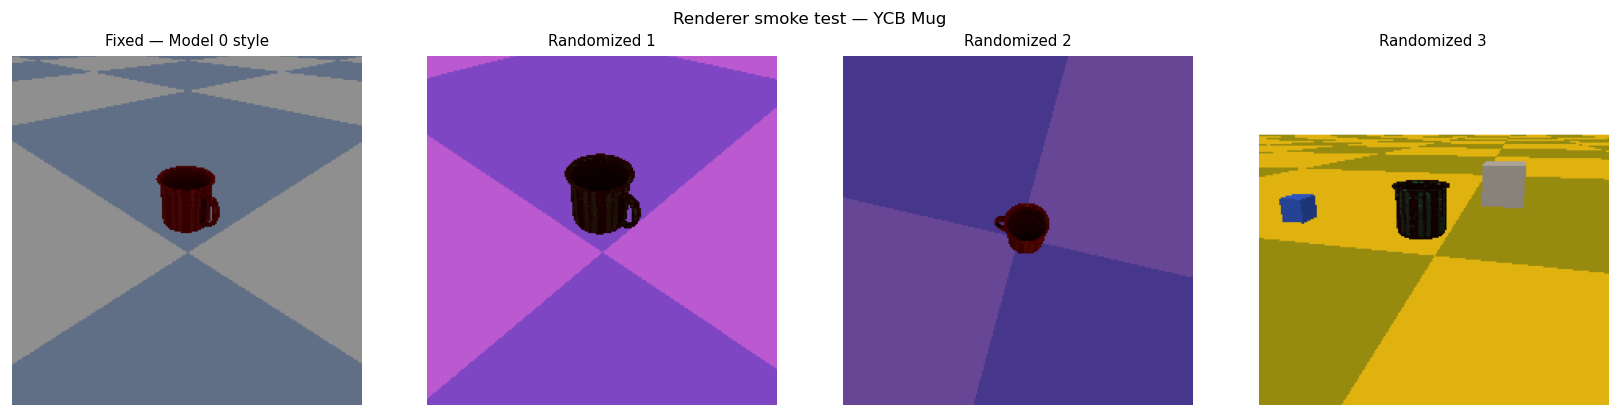

Renderer OK


In [4]:
class DomainRandomizedRenderer:
    """Renders YCB .obj meshes in PyBullet with visual domain randomization.
       Ref: Tobin et al. 2017."""

    def __init__(self, img_size=224):
        self.img_size = img_size
        self.physics_client = None

    def connect(self):
        if self.physics_client is not None:
            try: p.disconnect(self.physics_client)
            except Exception: pass
        self.physics_client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -9.81)

    def disconnect(self):
        if self.physics_client is not None:
            try: p.disconnect(self.physics_client)
            except Exception: pass
            self.physics_client = None

    def _random_color(self):
        return [random.random(), random.random(), random.random(), 1.0]

    def render_object(self, mesh_path, randomize=True,
                      distance=0.5, yaw=45, pitch=-35):
        p.resetSimulation()
        p.setGravity(0, 0, -9.81)

        plane_id    = p.loadURDF("plane.urdf")
        floor_color = self._random_color() if randomize else [0.6, 0.6, 0.6, 1.0]
        p.changeVisualShape(plane_id, -1, rgbaColor=floor_color)

        try:
            vis_id = p.createVisualShape(
                p.GEOM_MESH, fileName=str(mesh_path), meshScale=[1, 1, 1],
                rgbaColor=self._random_color() if randomize else [0.8, 0.2, 0.2, 1.0]
            )
            col_id = p.createCollisionShape(
                p.GEOM_MESH, fileName=str(mesh_path), meshScale=[1, 1, 1]
            )
            obj_id = p.createMultiBody(
                baseMass=0.1, baseCollisionShapeIndex=col_id,
                baseVisualShapeIndex=vis_id, basePosition=[0, 0, 0.05]
            )
        except Exception as e:
            print(f"Mesh load error ({mesh_path.name}): {e}")
            return None

        if randomize:
            p.changeVisualShape(obj_id, -1, rgbaColor=self._random_color())
            for _ in range(random.randint(0, 4)):
                pos  = [random.uniform(-0.3, 0.3),
                        random.uniform(-0.3, 0.3),
                        random.uniform(0.02, 0.15)]
                size = random.uniform(0.02, 0.08)
                vis  = p.createVisualShape(p.GEOM_BOX, halfExtents=[size]*3,
                                           rgbaColor=self._random_color())
                col  = p.createCollisionShape(p.GEOM_BOX, halfExtents=[size]*3)
                p.createMultiBody(0, col, vis, pos)

        if randomize:
            distance = random.uniform(0.35, 0.75)
            yaw      = random.uniform(0, 360)
            pitch    = random.uniform(-70, -15)

        view_mat = p.computeViewMatrixFromYawPitchRoll(
            cameraTargetPosition=[0, 0, 0.05],
            distance=distance, yaw=yaw, pitch=pitch, roll=0, upAxisIndex=2
        )
        proj_mat = p.computeProjectionMatrixFOV(
            fov=60, aspect=1.0, nearVal=0.01, farVal=10.0
        )
        _, _, rgb, _, _ = p.getCameraImage(
            width=self.img_size, height=self.img_size,
            viewMatrix=view_mat, projectionMatrix=proj_mat,
            renderer=p.ER_TINY_RENDERER
        )
        arr = np.array(rgb, dtype=np.uint8).reshape(self.img_size, self.img_size, 4)
        return Image.fromarray(arr[:, :, :3])


def get_mesh_path(obj_name):
    return MESH_DIR / obj_name / "google_16k" / "textured.obj"


def get_level_name(texture_level):
    return "no_randomization" if texture_level == 0 else f"textures_{texture_level:05d}"


# ── Smoke test ──────────────────────────────────────────────────────────────
renderer = DomainRandomizedRenderer(img_size=IMG_SIZE)
renderer.connect()
mug_mesh = get_mesh_path("025_mug")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (title, rand) in zip(axes, [
    ("Fixed — Model 0 style", False),
    ("Randomized 1", True), ("Randomized 2", True), ("Randomized 3", True),
]):
    ax.imshow(np.array(renderer.render_object(mug_mesh, randomize=rand)))
    ax.set_title(title, fontsize=9); ax.axis("off")

plt.suptitle("Renderer smoke test — YCB Mug", fontsize=10)
plt.tight_layout(); plt.show()
renderer.disconnect()
print("Renderer OK")

## Synthetic Dataset Generation

Generates **1,000 images per class × 5 classes × 6 levels = 30,000 images** into `synthetic_images_v2/{level_name}/{obj_name}/{i:04d}.png`.

**Fixed seed formula (the core V2 change):**

`cycle_seed = 42 + obj_idx × 1,000,000 + texture_level × 100 + (i % texture_level)`

The `texture_level × 100` term shifts each diversity level into its own seed range, so levels 500, 1000, and 5000 no longer produce identical data as they did in V1. With 1,000 images per class, Level 1000 now reaches its intended 1,000 genuinely unique renders.

> **Runtime note:** A fresh run generates all 30,000 images and takes about an hour on a laptop GPU. Generation is idempotent — images already on disk are skipped, so re-running after a completed run finishes in seconds.

In [6]:
def generate_dataset_v2(renderer, obj_name, texture_level,
                        images_per_class=1000, seed=42):
    """Generate synthetic training images for one (object, level) pair."""
    mesh_path  = get_mesh_path(obj_name)
    level_name = get_level_name(texture_level)
    obj_idx    = OBJECTS.index(obj_name)

    obj_dir = SYNTH_DIR_V2 / level_name / obj_name
    obj_dir.mkdir(parents=True, exist_ok=True)

    existing = len(list(obj_dir.glob("*.png")))
    if existing >= images_per_class:
        print(f"  {obj_name:35s} / {level_name}: complete — skipping")
        return

    print(f"  {obj_name:35s} / {level_name} ...", end="", flush=True)

    for i in range(images_per_class):
        img_path = obj_dir / f"{i:04d}.png"
        if img_path.exists():
            continue

        if texture_level == 0:
            img = renderer.render_object(mesh_path, randomize=False)
        else:
            cycle_seed = (seed
                          + obj_idx * 1_000_000
                          + texture_level * 100
                          + (i % texture_level))
            random.seed(cycle_seed)
            np.random.seed(cycle_seed)
            img = renderer.render_object(mesh_path, randomize=True)

        if img is not None:
            img.save(str(img_path))

    count = len(list(obj_dir.glob("*.png")))
    print(f" {count} images OK")


# ── Generation loop ─────────────────────────────────────────────────────────
TOTAL_JOBS_V2 = len(ALL_LEVELS) * len(OBJECTS)
print("=" * 66)
print(f"  V2 GENERATION — {TOTAL_JOBS_V2 * IMAGES_V2:,} images target")
print("=" * 66)

renderer_v2 = DomainRandomizedRenderer(img_size=IMG_SIZE)
renderer_v2.connect()

t0, completed, skipped, errors = time.time(), 0, 0, []
level_bar = tqdm(ALL_LEVELS, desc="Levels", unit="level", position=0)

for level in level_bar:
    label = get_level_name(level)
    level_bar.set_description(f"Level {label}")
    obj_bar = tqdm(OBJECTS, desc="  Objects", unit="obj", position=1, leave=False)

    for obj in obj_bar:
        obj_bar.set_description(f"  {obj}")
        obj_dir = SYNTH_DIR_V2 / label / obj
        n_exist = len(list(obj_dir.glob("*.png"))) if obj_dir.exists() else 0
        if n_exist >= IMAGES_V2:
            skipped += 1
            continue
        try:
            generate_dataset_v2(renderer_v2, obj, level, IMAGES_V2, seed=42)
            completed += 1
        except Exception as exc:
            errors.append(f"{label}/{obj}: {exc}")
            tqdm.write(f"  ERROR: {errors[-1]}")
    obj_bar.close()

renderer_v2.disconnect()
print(f"\nDone in {(time.time()-t0)/60:.1f} min  |  "
      f"Generated: {completed}  Skipped: {skipped}  Errors: {len(errors)}")

for level in ALL_LEVELS:
    lname    = get_level_name(level)
    expected = len(OBJECTS) * IMAGES_V2
    total    = sum(len(list((SYNTH_DIR_V2 / lname / o).glob("*.png")))
                   for o in OBJECTS if (SYNTH_DIR_V2 / lname / o).exists())
    print(f"  {lname:<26} {total:>8,}  {'OK' if total==expected else 'INCOMPLETE'}")

  V2 GENERATION — 30,000 images target


Levels:   0%|          | 0/6 [00:00<?, ?level/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]

  Objects:   0%|          | 0/5 [00:00<?, ?obj/s]


Done in 0.0 min  |  Generated: 0  Skipped: 30  Errors: 0
  no_randomization              5,000  OK
  textures_00010                5,000  OK
  textures_00100                5,000  OK
  textures_00500                5,000  OK
  textures_01000                5,000  OK
  textures_05000                5,000  OK


## Datasets and Transforms

Two dataset classes with the same label scheme (`OBJECTS.index(obj_name)` → 0–4):

- **`SyntheticDataset_V2(texture_level)`** — loads simulated training images from `synthetic_images_v2/`
- **`RealYCBDataset()`** — loads the real YCB test photographs; never seen during training

Training transform: resize → random horizontal flip → ImageNet normalisation (no colour jitter, since domain randomization already provides colour diversity). Test transform: resize → normalise only (deterministic).

In [7]:
# ── Transforms ─────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])


class SyntheticDataset_V2(Dataset):
    """Simulated training images for one texture level. Label = 0..4."""
    def __init__(self, texture_level, transform=None):
        self.transform = transform
        self.samples   = []
        level_name     = get_level_name(texture_level)
        for class_idx, obj_name in enumerate(OBJECTS):
            obj_dir = SYNTH_DIR_V2 / level_name / obj_name
            if not obj_dir.exists():
                print(f"  WARNING — missing: {obj_dir}")
                continue
            for img_path in sorted(obj_dir.glob("*.png")):
                self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


class RealYCBDataset(Dataset):
    """Real YCB RGB test images. Label = 0..4. Never used during training."""
    def __init__(self, transform=None):
        self.transform = transform
        self.samples   = []
        for class_idx, obj_name in enumerate(OBJECTS):
            obj_dir = RGB_DIR / obj_name
            if not obj_dir.exists():
                print(f"  WARNING — missing: {obj_dir}")
                continue
            imgs = (list(obj_dir.rglob("*.jpg"))  +
                    list(obj_dir.rglob("*.JPG"))  +
                    list(obj_dir.rglob("*.jpeg")) +
                    list(obj_dir.rglob("*.png")))
            for pth in sorted(set(imgs)):
                self.samples.append((pth, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Sanity check ────────────────────────────────────────────────────────────
print(f"Class map: {CLASS_MAP}\n")

print("Synthetic training sets (V2):")
for level in ALL_LEVELS:
    ds       = SyntheticDataset_V2(level)
    expected = len(OBJECTS) * IMAGES_V2
    flag     = "OK" if len(ds) == expected else f"WARNING — expected {expected}"
    print(f"  {get_level_name(level):<26}: {len(ds):>6} images  {flag}")

real_ds = RealYCBDataset()
print(f"\nReal YCB test set: {len(real_ds)} images")
for i, obj in enumerate(OBJECTS):
    count = sum(1 for _, l in real_ds.samples if l == i)
    print(f"  Class {i} — {obj}: {count} images")

Class map: {0: '025_mug', 1: '006_mustard_bottle', 2: '035_power_drill', 3: '024_bowl', 4: '021_bleach_cleanser'}

Synthetic training sets (V2):
  no_randomization          :   5000 images  OK
  textures_00010            :   5000 images  OK
  textures_00100            :   5000 images  OK
  textures_00500            :   5000 images  OK
  textures_01000            :   5000 images  OK
  textures_05000            :   5000 images  OK

Real YCB test set: 3000 images
  Class 0 — 025_mug: 600 images
  Class 1 — 006_mustard_bottle: 600 images
  Class 2 — 035_power_drill: 600 images
  Class 3 — 024_bowl: 600 images
  Class 4 — 021_bleach_cleanser: 600 images


## Model and Training

**Architecture:** ResNet-18 pretrained on ImageNet, final FC layer replaced (`Linear(512 → 5)`). All layers trainable — no freezing.

**Loss:** CrossEntropyLoss. **Optimiser:** Adam (lr=1e-4). **Scheduler:** ReduceLROnPlateau on training loss.

**Training:** fixed 10 epochs, no early stopping and no validation split — this simpler scheme is what V2 used. (Early stopping with a stratified validation split was only introduced in V3.) Each model trains on all 5,000 synthetic images for its level.

**Checkpointing:** each model saves to `trained_models_v2/model_{level_name}.pth`. Re-running skips levels whose checkpoints already exist.

In [8]:
def build_model(num_classes=5):
    """ResNet-18 pretrained on ImageNet, final FC replaced. All layers trainable."""
    model    = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def train_one_level_v2(texture_level, epochs=EPOCHS, verbose=True):
    """Train one ResNet-18 for fixed epochs. Saves to MODELS_DIR_V2."""
    level_name = get_level_name(texture_level)
    model_path = MODELS_DIR_V2 / f"model_{level_name}.pth"

    if model_path.exists():
        ckpt = torch.load(model_path, map_location="cpu")
        if verbose:
            print(f"  [{level_name}] checkpoint found "
                  f"(final train acc {ckpt['history']['acc'][-1]:.1f}%) — skipping")
        return ckpt.get("history")

    if verbose:
        print(f"\n{'─'*58}")
        print(f"  V2 Training : {level_name}")
        print(f"{'─'*58}")

    dataset   = SyntheticDataset_V2(texture_level, transform=train_transform)
    loader    = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=0, pin_memory=True)
    model     = build_model()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )
    history = {"loss": [], "acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            _, preds  = logits.max(1)
            total    += labels.size(0)
            correct  += preds.eq(labels).sum().item()

        ep_loss = run_loss / total
        ep_acc  = 100.0 * correct / total
        history["loss"].append(round(ep_loss, 5))
        history["acc"].append(round(ep_acc, 2))
        scheduler.step(ep_loss)

        if verbose:
            print(f"  Epoch {epoch:02d}/{epochs}  "
                  f"loss={ep_loss:.4f}  train_acc={ep_acc:5.1f}%")

    torch.save({
        "texture_level": texture_level, "level_name": level_name,
        "model_state": model.state_dict(), "history": history,
        "objects": OBJECTS, "num_classes": len(OBJECTS),
    }, model_path)
    if verbose:
        print(f"  Saved → {model_path.name}")
    return history


# ── Train all 6 V2 models ──────────────────────────────────────────────────
print("=" * 58)
print("  V2 TRAINING — fixed 10 epochs")
print("=" * 58)

all_histories_v2 = {}
t_start = time.time()
for level in ALL_LEVELS:
    t0 = time.time()
    h  = train_one_level_v2(level, epochs=EPOCHS, verbose=True)
    if h:
        all_histories_v2[level] = h
    if time.time() - t0 > 5:
        print(f"  → {(time.time()-t0)/60:.1f} min\n")

print(f"\nAll V2 models ready — {(time.time()-t_start)/60:.1f} min total")
print(f"\n  {'Level':<26}  {'Train acc':>9}  {'Loss':>7}")
print(f"  {'-'*26}  {'-'*9}  {'-'*7}")
for level in ALL_LEVELS:
    name  = get_level_name(level)
    fpath = MODELS_DIR_V2 / f"model_{name}.pth"
    if fpath.exists():
        h = torch.load(fpath, map_location="cpu")["history"]
        print(f"  {name:<26}  {h['acc'][-1]:>8.1f}%  {h['loss'][-1]:>7.4f}")

  V2 TRAINING — fixed 10 epochs
  [no_randomization] checkpoint found (final train acc 100.0%) — skipping
  [textures_00010] checkpoint found (final train acc 100.0%) — skipping
  [textures_00100] checkpoint found (final train acc 100.0%) — skipping
  [textures_00500] checkpoint found (final train acc 100.0%) — skipping
  [textures_01000] checkpoint found (final train acc 99.9%) — skipping
  [textures_05000] checkpoint found (final train acc 99.9%) — skipping

All V2 models ready — 0.0 min total

  Level                       Train acc     Loss
  --------------------------  ---------  -------
  no_randomization               100.0%   0.0000
  textures_00010                 100.0%   0.0001
  textures_00100                 100.0%   0.0004
  textures_00500                 100.0%   0.0015
  textures_01000                  99.9%   0.0057
  textures_05000                  99.9%   0.0045


## Evaluation on Real YCB Images

Each trained model is evaluated on the 3,000 real YCB test photographs. We record overall top-1 accuracy, per-class accuracy, and the confusion matrix per level. Random chance for 5 classes is 20%.

This is where the V2 seed fix shows its effect: with levels now genuinely distinct, Level 1000 emerges as the clear peak — a result that was impossible to observe in V1, where levels 500/1000/5000 trained on identical data.

In [9]:
def evaluate_model_v2(texture_level):
    """Load saved V2 model, evaluate on real YCB images.
       Returns (overall, per_class dict, confusion_matrix 5x5)."""
    level_name = get_level_name(texture_level)
    model_path = MODELS_DIR_V2 / f"model_{level_name}.pth"
    if not model_path.exists():
        return None, None, None

    ckpt  = torch.load(model_path, map_location=device)
    model = build_model()
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    loader = DataLoader(RealYCBDataset(transform=test_transform),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            _, preds = model(imgs.to(device)).max(1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.tolist())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    overall    = 100.0 * (all_preds == all_labels).mean()
    per_class  = {obj: 100.0 * (all_preds[all_labels == i] == i).mean()
                  for i, obj in enumerate(OBJECTS) if (all_labels == i).sum() > 0}

    n  = len(OBJECTS)
    cm = np.zeros((n, n), dtype=int)
    for t_, p_ in zip(all_labels, all_preds):
        cm[t_, p_] += 1
    return float(overall), per_class, cm


# ── Evaluate all 6 V2 models ───────────────────────────────────────────────
print("=" * 66)
print("  V2 EVALUATION — Real YCB Test Images")
print("=" * 66 + "\n")

results_v2   = {}
confusion_v2 = {}
for level in ALL_LEVELS:
    name = get_level_name(level)
    overall, per_class, cm = evaluate_model_v2(level)
    if overall is not None:
        results_v2[level]   = {"overall": overall, "per_class": per_class}
        confusion_v2[level] = cm
        pc = "  ".join(f"{per_class[o]:.0f}%" for o in OBJECTS)
        print(f"  {name:<26} overall={overall:5.1f}%  per-class: {pc}")

# Summary table
short = [o.split("_", 1)[1].replace("_", " ")[:8] for o in OBJECTS]
print(f"\n  {'Level':<26}  {'Overall':>7}  " + "  ".join(f"{s:>8}" for s in short))
for level in ALL_LEVELS:
    name = get_level_name(level)
    if level in results_v2:
        r   = results_v2[level]
        cls = "  ".join(f"{r['per_class'].get(o,0):>7.1f}%" for o in OBJECTS)
        print(f"  {name:<26}  {r['overall']:>6.1f}%  {cls}")

# Save CSV
csv_path = RESULTS_DIR_V2 / "accuracy_results_v2.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["texture_level", "level_name", "overall"] + OBJECTS)
    for level in ALL_LEVELS:
        name = get_level_name(level)
        if level in results_v2:
            r = results_v2[level]
            w.writerow([level, name, round(r["overall"], 2)] +
                       [round(r["per_class"].get(o, 0), 2) for o in OBJECTS])
print(f"\n  Saved → {csv_path}")

  V2 EVALUATION — Real YCB Test Images

  no_randomization           overall=  9.9%  per-class: 21%  0%  29%  0%  0%
  textures_00010             overall= 49.9%  per-class: 0%  10%  72%  70%  98%
  textures_00100             overall= 38.3%  per-class: 11%  39%  100%  5%  37%
  textures_00500             overall= 42.0%  per-class: 9%  26%  80%  4%  90%
  textures_01000             overall= 65.3%  per-class: 97%  79%  78%  0%  72%
  textures_05000             overall= 40.8%  per-class: 18%  52%  100%  5%  29%

  Level                       Overall       mug  mustard   power dr      bowl  bleach c
  no_randomization               9.9%     20.8%      0.0%     28.7%      0.0%      0.2%
  textures_00010                49.9%      0.0%     10.0%     71.5%     70.3%     97.5%
  textures_00100                38.3%     10.7%     38.8%     99.5%      5.3%     37.2%
  textures_00500                42.0%      8.8%     26.3%     80.5%      3.7%     90.5%
  textures_01000                65.3%     97.3

## Results — Accuracy vs Texture Diversity

Overall top-1 accuracy on real YCB images versus texture diversity level. With the seed formula fixed, the curve is non-monotonic and peaks clearly at Level 1000 (65.3%) — the key V2 result. The peak at Level 1000 is consistent with V3, showing the finding is robust across data scales.

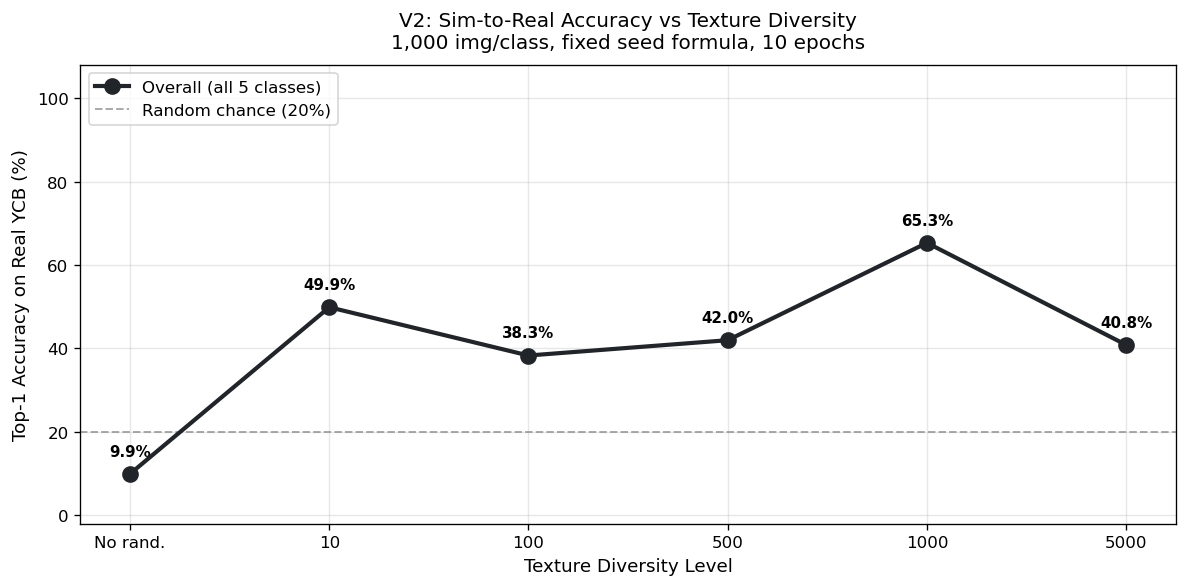

Saved → C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\results_v2\accuracy_curve_overall.png


In [10]:
# ── Accuracy vs diversity — overall ────────────────────────────────────────
x_pos   = list(range(len(ALL_LEVELS)))
x_ticks = ["No rand." if l == 0 else str(l) for l in ALL_LEVELS]

fig, ax = plt.subplots(figsize=(10, 5))
overall_vals = [results_v2[l]["overall"] if l in results_v2 else None
                for l in ALL_LEVELS]

ax.plot(x_pos, overall_vals, "o-", color="#212529",
        linewidth=2.5, markersize=9,
        label="Overall (all 5 classes)", zorder=5)
for x, y in zip(x_pos, overall_vals):
    if y is not None:
        ax.annotate(f"{y:.1f}%", xy=(x, y), xytext=(0, 11),
                    textcoords="offset points", ha="center",
                    fontsize=9, fontweight="bold")

ax.axhline(20, color="#888", linestyle="--", linewidth=1.2, alpha=0.7,
           label="Random chance (20%)")
ax.set_xticks(x_pos); ax.set_xticklabels(x_ticks, fontsize=10)
ax.set_xlabel("Texture Diversity Level", fontsize=11)
ax.set_ylabel("Top-1 Accuracy on Real YCB (%)", fontsize=11)
ax.set_title("V2: Sim-to-Real Accuracy vs Texture Diversity\n"
             "1,000 img/class, fixed seed formula, 10 epochs",
             fontsize=12, pad=10)
ax.set_ylim(-2, 108)
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = RESULTS_DIR_V2 / "accuracy_curve_overall.png"
plt.savefig(str(out), dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Results — Confusion Matrices

Per-level confusion matrices on the real test set (rows = true class, columns = predicted, values = % of that true class). These show how each model fails: at no randomization predictions collapse onto a couple of classes, at Level 10 the model exploits a single-class shortcut, and at Level 1000 the diagonal is strongest.

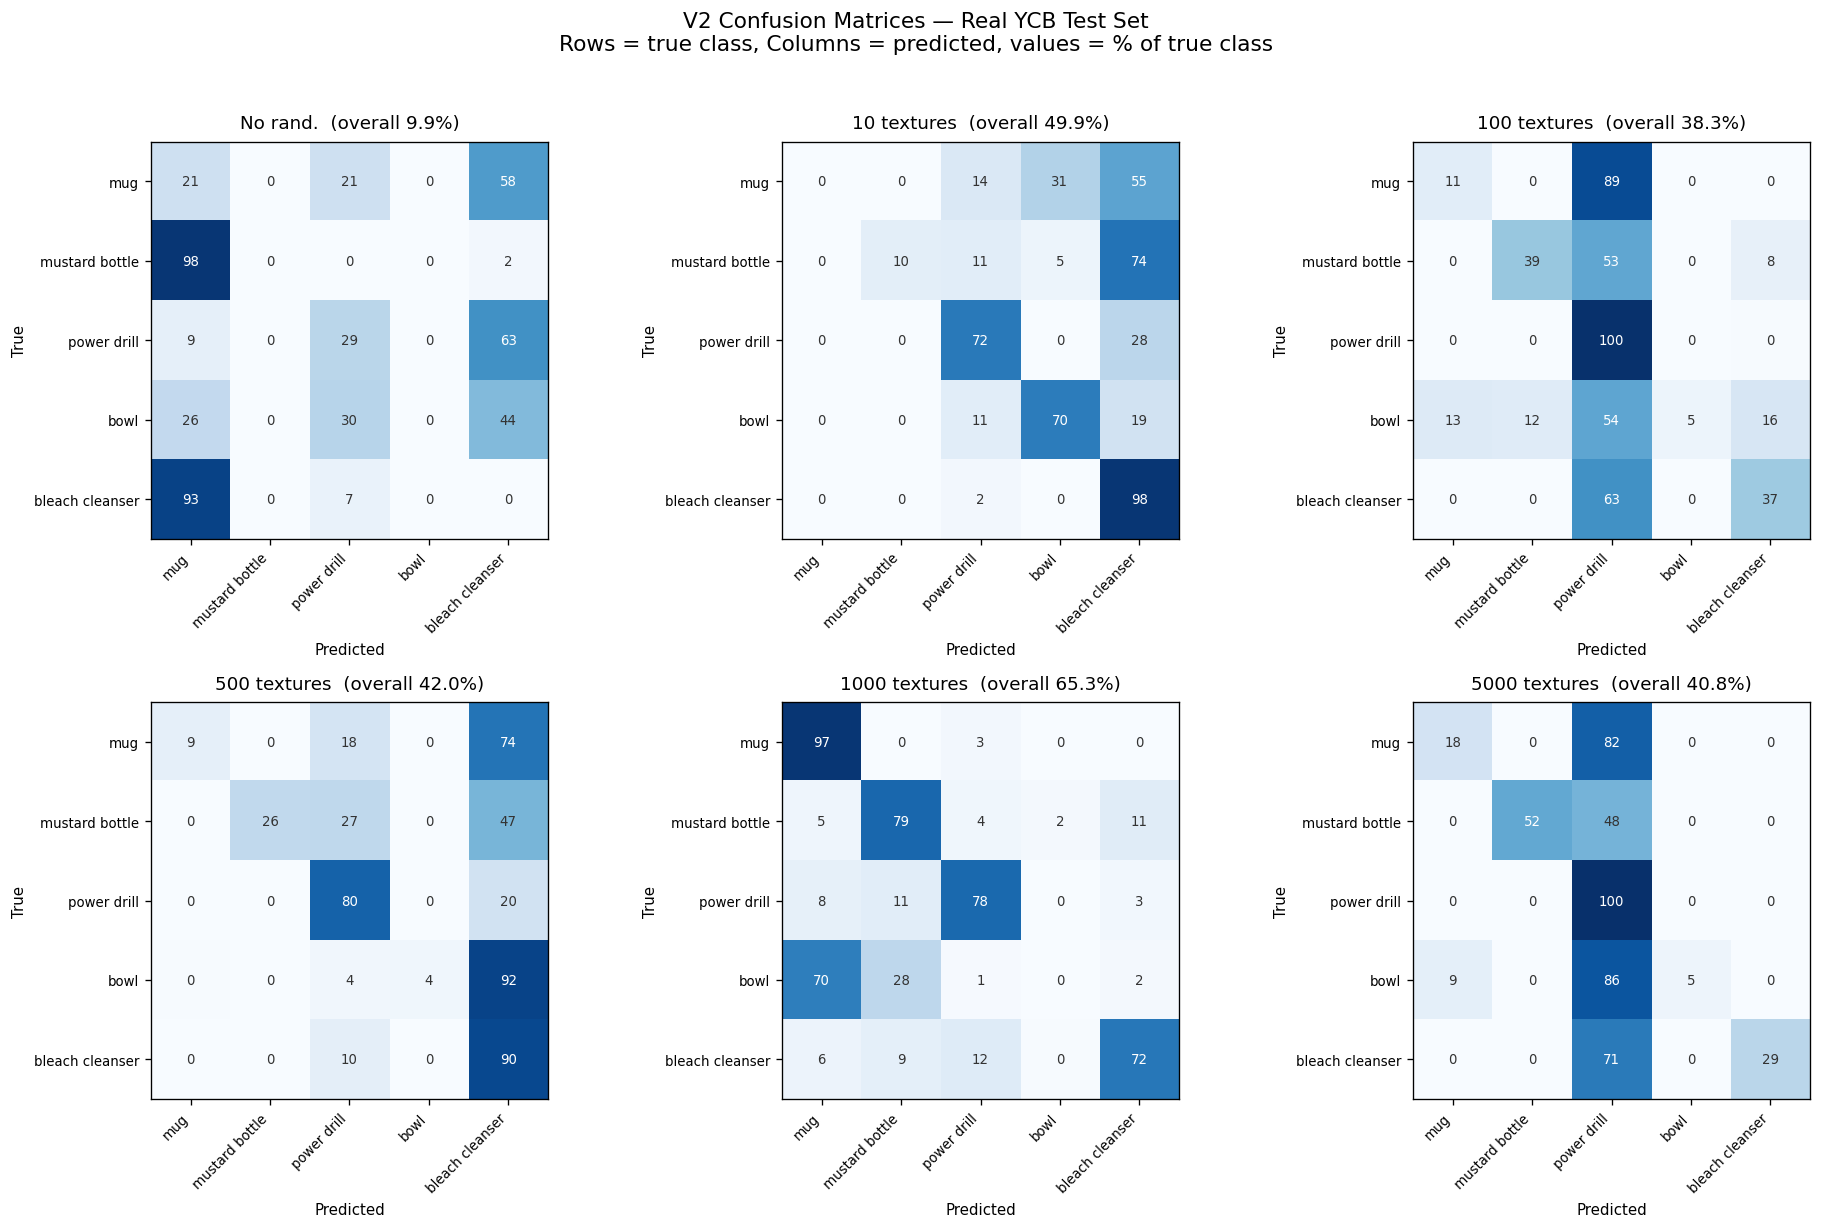

Saved → C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\results_v2\confusion_matrices_v2.png


In [11]:
# ── Confusion matrices — all 6 levels, 2x3 grid ────────────────────────────
short_labels = [o.split("_", 1)[1].replace("_", " ") for o in OBJECTS]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flat

for ax, level in zip(axes, ALL_LEVELS):
    if level not in confusion_v2:
        ax.axis("off"); continue
    cm     = confusion_v2[level]
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    name    = "No rand." if level == 0 else f"{level} textures"
    overall = results_v2[level]["overall"]
    ax.set_title(f"{name}  (overall {overall:.1f}%)", fontsize=11, pad=8)

    ax.set_xticks(range(len(OBJECTS))); ax.set_yticks(range(len(OBJECTS)))
    ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(short_labels, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9); ax.set_ylabel("True", fontsize=9)

    for i in range(len(OBJECTS)):
        for j in range(len(OBJECTS)):
            v = cm_pct[i, j]
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    fontsize=8, color="white" if v > 50 else "#333")

plt.suptitle("V2 Confusion Matrices — Real YCB Test Set\n"
             "Rows = true class, Columns = predicted, values = % of true class",
             fontsize=13, y=1.02)
plt.tight_layout()
out = RESULTS_DIR_V2 / "confusion_matrices_v2.png"
plt.savefig(str(out), dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## Grad-CAM — What the Models Attend To

Grad-CAM (Selvaraju et al. 2017) shows where each model looks when predicting, by backpropagating the target class score through ResNet-18's last convolutional block. We compare the no-randomization model against the best-performing model for each class. The shift from attending to background to attending to the object is the qualitative evidence that domain randomization changes the learned representation.

In [12]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping for ResNet-18. Ref: Selvaraju 2017."""
    def __init__(self, model):
        self.model      = model.eval()
        self._features  = None
        self._gradients = None
        self._hooks     = []
        target = model.layer4[-1]
        self._hooks.append(target.register_forward_hook(self._fwd_hook))
        self._hooks.append(target.register_full_backward_hook(self._bwd_hook))

    def _fwd_hook(self, m, i, o): self._features = o.detach()
    def _bwd_hook(self, m, gi, go): self._gradients = go[0].detach()

    def generate(self, img_tensor, class_idx=None):
        img_tensor = img_tensor.to(device)
        self.model.zero_grad()
        logits = self.model(img_tensor)
        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())
        logits[0, class_idx].backward()
        weights = self._gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self._features).sum(dim=1, keepdim=True)).squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        H, W = img_tensor.shape[2], img_tensor.shape[3]
        return cv2.resize(cam, (W, H)), class_idx

    def remove_hooks(self):
        for h in self._hooks: h.remove()


def overlay_cam(orig_pil, cam, alpha=0.45):
    orig_np  = np.array(orig_pil.resize((IMG_SIZE, IMG_SIZE)))
    heat_rgb = cv2.cvtColor(
        cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB)
    return Image.fromarray((alpha * heat_rgb + (1 - alpha) * orig_np).astype(np.uint8))


def load_model_weights_v2(texture_level):
    ckpt  = torch.load(MODELS_DIR_V2 / f"model_{get_level_name(texture_level)}.pth",
                       map_location=device)
    model = build_model()
    model.load_state_dict(ckpt["model_state"])
    return model.eval()


print("GradCAM ready | overlay_cam ready | load_model_weights_v2 ready")

GradCAM ready | overlay_cam ready | load_model_weights_v2 ready


Best V2 model per class:
  025_mug                             → Level 1000 (97.3%)
  006_mustard_bottle                  → Level 1000 (78.7%)
  035_power_drill                     → Level 5000 (100.0%)
  024_bowl                            → Level 10 (70.3%)
  021_bleach_cleanser                 → Level 10 (97.5%)


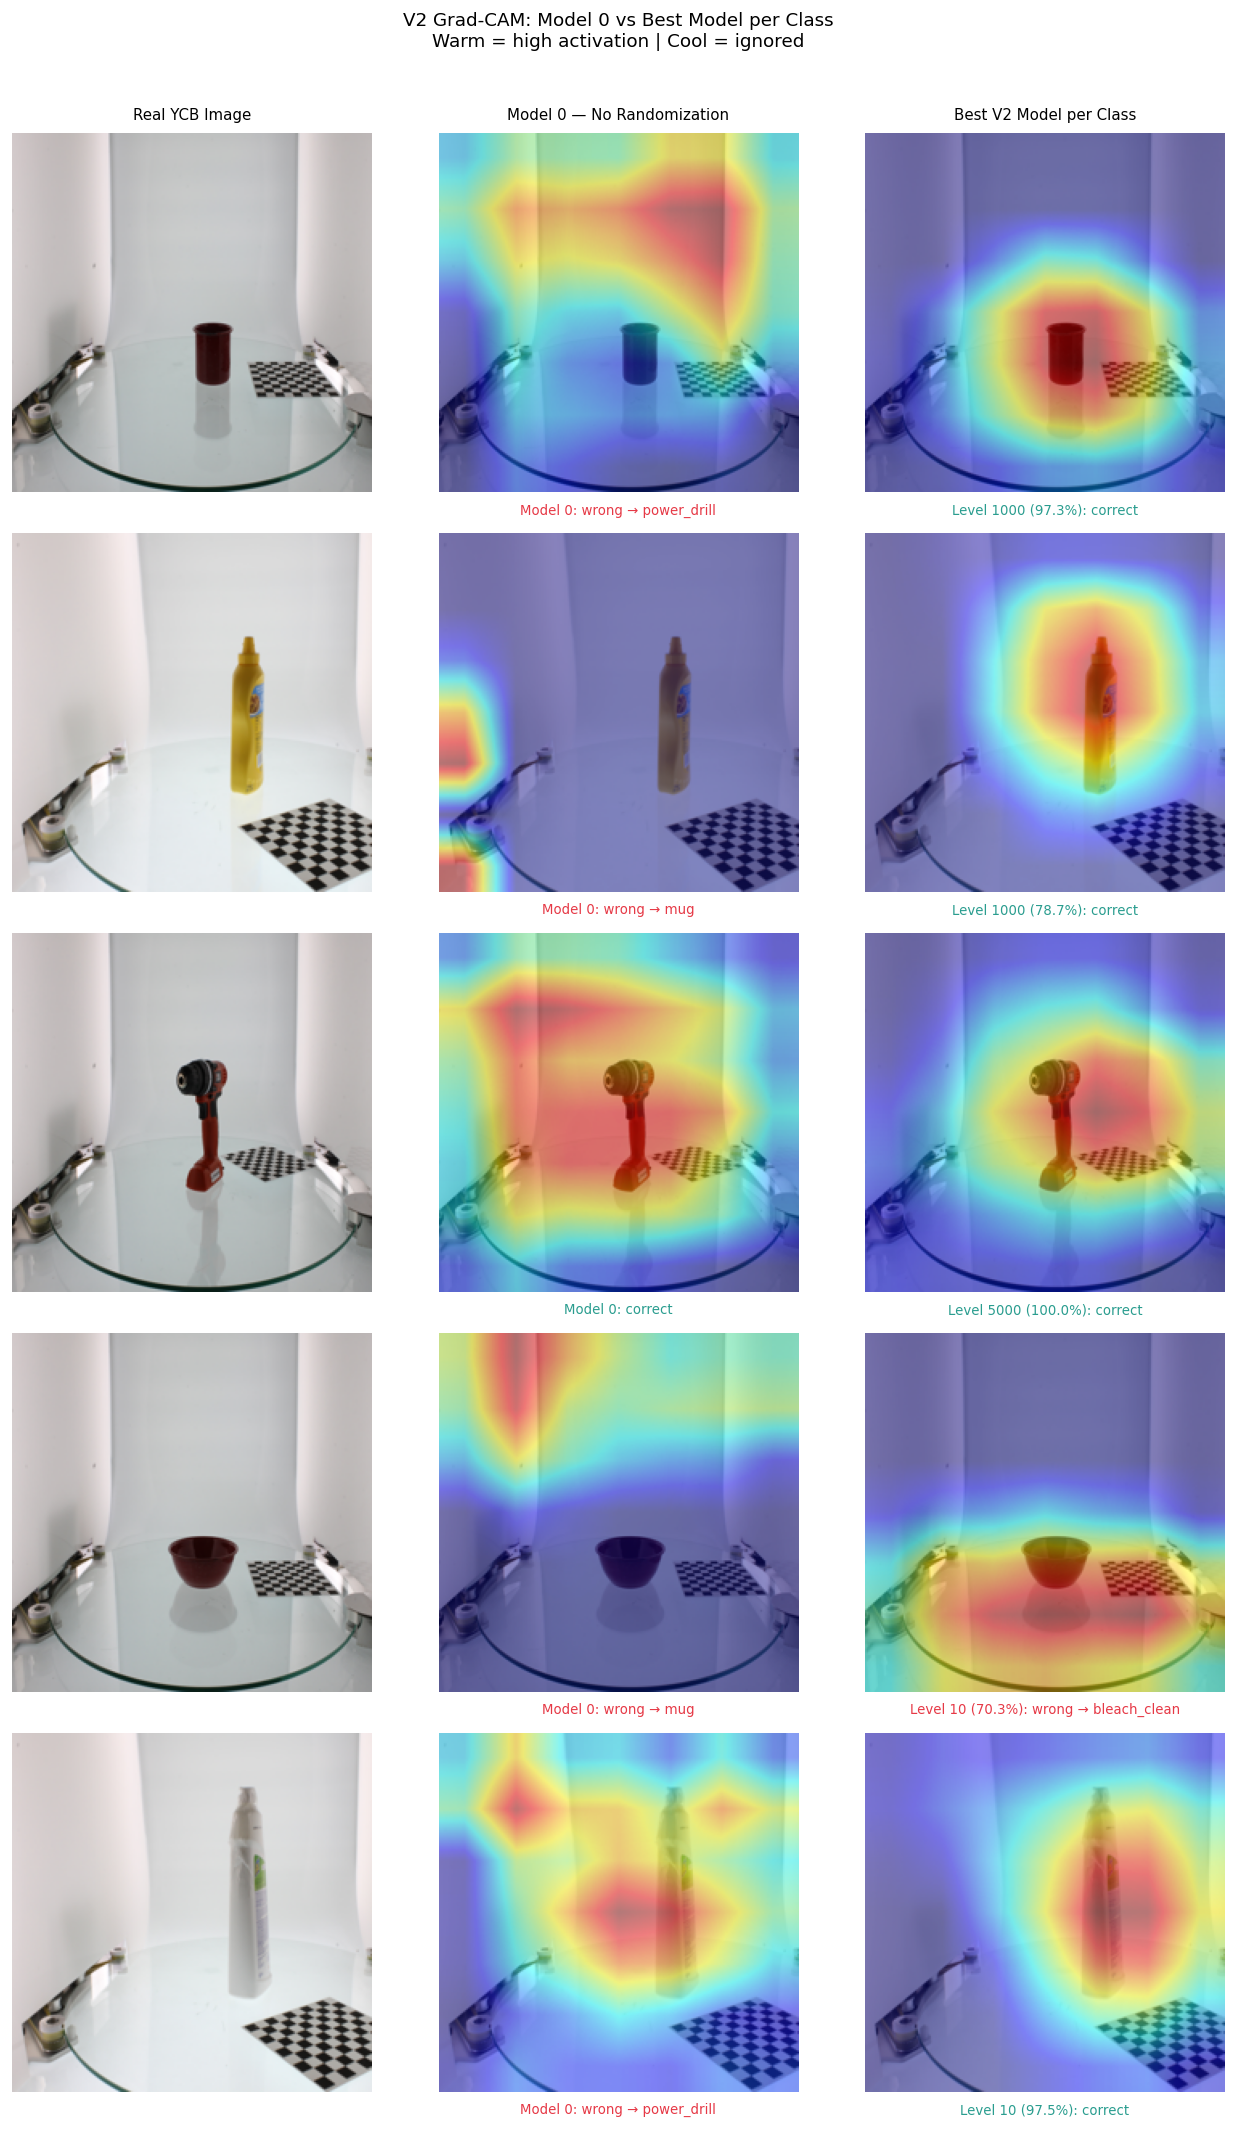

Saved → C:\Universty COURSES\4th semester\Seminar in AI_Physical Ai\Experiment\results_v2\gradcam_v2_per_class_best.png


In [13]:
# ── Grad-CAM: Model 0 vs best model per class ──────────────────────────────
best_level_v2, best_acc_v2 = {}, {}
for i, obj in enumerate(OBJECTS):
    accs = {l: results_v2[l]["per_class"].get(obj, 0)
            for l in ALL_LEVELS if l in results_v2 and l != 0}
    bl = max(accs, key=accs.get)
    best_level_v2[obj], best_acc_v2[obj] = bl, accs[bl]

print("Best V2 model per class:")
for obj in OBJECTS:
    print(f"  {obj:35s} → Level {best_level_v2[obj]} ({best_acc_v2[obj]:.1f}%)")

SAMPLE_IDX = 10
sample_images = []
for class_idx, obj_name in enumerate(OBJECTS):
    imgs = sorted(list((RGB_DIR / obj_name).rglob("*.jpg")) +
                  list((RGB_DIR / obj_name).rglob("*.JPG")))
    if imgs:
        sample_images.append((imgs[min(SAMPLE_IDX, len(imgs)-1)], class_idx, obj_name))

model_0 = load_model_weights_v2(0)
cam_0   = GradCAM(model_0)

fig, axes = plt.subplots(len(sample_images), 3, figsize=(11, 3.5*len(sample_images)))
axes[0,0].set_title("Real YCB Image", fontsize=9, pad=8)
axes[0,1].set_title("Model 0 — No Randomization", fontsize=9, pad=8)
axes[0,2].set_title("Best V2 Model per Class", fontsize=9, pad=8)

for row, (img_path, true_class, obj_name) in enumerate(sample_images):
    orig  = Image.open(img_path).convert("RGB")
    img_t = test_transform(orig).unsqueeze(0)
    short = obj_name.split("_", 1)[1].replace("_", " ")
    blevel, bacc = best_level_v2[obj_name], best_acc_v2[obj_name]

    axes[row,0].imshow(orig.resize((IMG_SIZE, IMG_SIZE)))
    axes[row,0].set_ylabel(f"Class {true_class}\n{short}", fontsize=8,
                           rotation=90, labelpad=5, va="center")
    axes[row,0].axis("off")

    with torch.no_grad():
        pred0 = int(model_0(img_t.clone().to(device)).argmax(1).item())
    c0 = pred0 == true_class
    h0, _ = cam_0.generate(img_t.clone(), class_idx=true_class)
    axes[row,1].imshow(overlay_cam(orig, h0)); axes[row,1].axis("off")
    axes[row,1].text(0.5, -0.03,
                     f"Model 0: {'correct' if c0 else 'wrong → '+OBJECTS[pred0].split('_',1)[1][:12]}",
                     transform=axes[row,1].transAxes, ha="center", va="top",
                     fontsize=8, color="#2A9D8F" if c0 else "#E63946")

    mbest = load_model_weights_v2(blevel)
    with torch.no_grad():
        predb = int(mbest(img_t.clone().to(device)).argmax(1).item())
    cb = predb == true_class
    cam_b = GradCAM(mbest)
    hb, _ = cam_b.generate(img_t.clone(), class_idx=true_class)
    axes[row,2].imshow(overlay_cam(orig, hb)); axes[row,2].axis("off")
    axes[row,2].text(0.5, -0.03,
                     f"Level {blevel} ({bacc:.1f}%): {'correct' if cb else 'wrong → '+OBJECTS[predb].split('_',1)[1][:12]}",
                     transform=axes[row,2].transAxes, ha="center", va="top",
                     fontsize=8, color="#2A9D8F" if cb else "#E63946")
    cam_b.remove_hooks(); del mbest, cam_b

plt.suptitle("V2 Grad-CAM: Model 0 vs Best Model per Class\n"
             "Warm = high activation | Cool = ignored", fontsize=11, y=1.01)
plt.tight_layout()
out = RESULTS_DIR_V2 / "gradcam_v2_per_class_best.png"
plt.savefig(str(out), dpi=200, bbox_inches="tight")
plt.show()
cam_0.remove_hooks(); del model_0
print(f"Saved → {out}")